In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

RANDOM_STATE = 42
sns.set_style("whitegrid")
np.random.seed(RANDOM_STATE)

In [2]:
DATA_PATH = "house_prices.csv"   # place your Kaggle CSV here to use real data

def generate_synthetic_housing_data(n=1500):
    '''Realistic synthetic housing dataset used only if house_prices.csv is not found.'''
    area = np.random.normal(1800, 700, n).clip(400, 6000)
    bedrooms = np.random.choice([1, 2, 3, 4, 5, 6], n, p=[0.05, 0.15, 0.30, 0.30, 0.15, 0.05])
    bathrooms = np.clip(np.round(bedrooms * np.random.uniform(0.5, 1.0, n)), 1, 5)
    stories = np.random.choice([1, 2, 3], n, p=[0.45, 0.45, 0.10])
    age = np.random.exponential(15, n).clip(0, 80)
    garage = np.random.choice([0, 1, 2, 3], n, p=[0.15, 0.35, 0.40, 0.10])
    lot_size = area * np.random.uniform(1.2, 3.0, n)
    location = np.random.choice(["Downtown", "Suburb", "Rural"], n, p=[0.3, 0.5, 0.2])
    condition = np.random.choice(["Poor", "Fair", "Good", "Excellent"], n, p=[0.1, 0.25, 0.45, 0.2])

    location_premium = pd.Series(location).map({"Downtown": 1.35, "Suburb": 1.0, "Rural": 0.75}).values
    condition_premium = pd.Series(condition).map({"Poor": 0.8, "Fair": 0.92, "Good": 1.05, "Excellent": 1.25}).values

    base_price = (
        area * 120
        + bedrooms * 8000
        + bathrooms * 6000
        + stories * 4000
        + garage * 5000
        - age * 900
        + lot_size * 8
    )
    price = base_price * location_premium * condition_premium
    price = price * np.random.normal(1.0, 0.12, n)   # noise
    price = price.clip(30000, None)

    df = pd.DataFrame({
        "Area": area.round(0),
        "Bedrooms": bedrooms.astype(int),
        "Bathrooms": bathrooms.astype(int),
        "Stories": stories.astype(int),
        "Age": age.round(1),
        "Garage": garage.astype(int),
        "LotSize": lot_size.round(0),
        "Location": location,
        "Condition": condition,
        "Price": price.round(-2),
    })

    # Inject some realistic missingness
    missing_idx_age = np.random.choice(df.index, size=int(0.05 * n), replace=False)
    df.loc[missing_idx_age, "Age"] = np.nan
    missing_idx_lot = np.random.choice(df.index, size=int(0.03 * n), replace=False)
    df.loc[missing_idx_lot, "LotSize"] = np.nan

    return df

try:
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded real dataset from {DATA_PATH}, shape: {df.shape}")
except FileNotFoundError:
    df = generate_synthetic_housing_data()
    print(f"'{DATA_PATH}' not found -- using a generated synthetic housing dataset instead.")
    print(f"Shape: {df.shape}")

df.head()

'house_prices.csv' not found -- using a generated synthetic housing dataset instead.
Shape: (1500, 10)


,Area,Bedrooms,Bathrooms,Stories,Age,Garage,LotSize,Location,Condition,Price
0,2148.0,3,2,3,12.1,2,5382.0,Rural,Good,310500.0
1,1703.0,5,4,2,NaN,2,2748.0,Downtown,Fair,415500.0
2,2253.0,3,3,2,2.0,1,2708.0,Downtown,Fair,484600.0
3,2866.0,2,2,2,11.3,1,7129.0,Downtown,Fair,522600.0
4,1636.0,2,1,1,4.7,1,2467.0,Suburb,Excellent,286600.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Area       1500 non-null   float64
 1   Bedrooms   1500 non-null   int64  
 2   Bathrooms  1500 non-null   int64  
 3   Stories    1500 non-null   int64  
 4   Age        1425 non-null   float64
 5   Garage     1500 non-null   int64  
 6   LotSize    1455 non-null   float64
 7   Location   1500 non-null   object 
 8   Condition  1500 non-null   object 
 9   Price      1500 non-null   float64
dtypes: float64(4), int64(4), object(2)
memory usage: 117.3+ KB


In [4]:
df.describe()

,Area,Bedrooms,Bathrooms,Stories,Age,Garage,LotSize,Price
count,1500.000000,1500.000000,1500.000000,1500.000000,1425.000000,1500.000000,1455.000000,1.500000e+03
mean,1838.540667,3.500667,2.652000,1.654000,14.153684,1.432667,3851.002062,3.203335e+05
std,682.975315,1.199010,1.058762,0.659222,14.009770,0.844161,1746.701238,1.419747e+05
min,400.000000,1.000000,1.000000,1.000000,0.000000,0.000000,480.000000,5.310000e+04
25%,1363.000000,3.000000,2.000000,1.000000,4.000000,1.000000,2524.500000,2.193750e+05
50%,1835.000000,4.000000,3.000000,2.000000,9.900000,1.000000,3671.000000,2.988500e+05
75%,2276.250000,4.000000,3.000000,2.000000,19.600000,2.000000,4997.500000,3.975750e+05
max,4497.000000,6.000000,5.000000,3.000000,80.000000,3.000000,10838.000000,1.084900e+06


In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})[missing > 0]

,missing_count,missing_pct
Age,75,5.0
LotSize,45,3.0


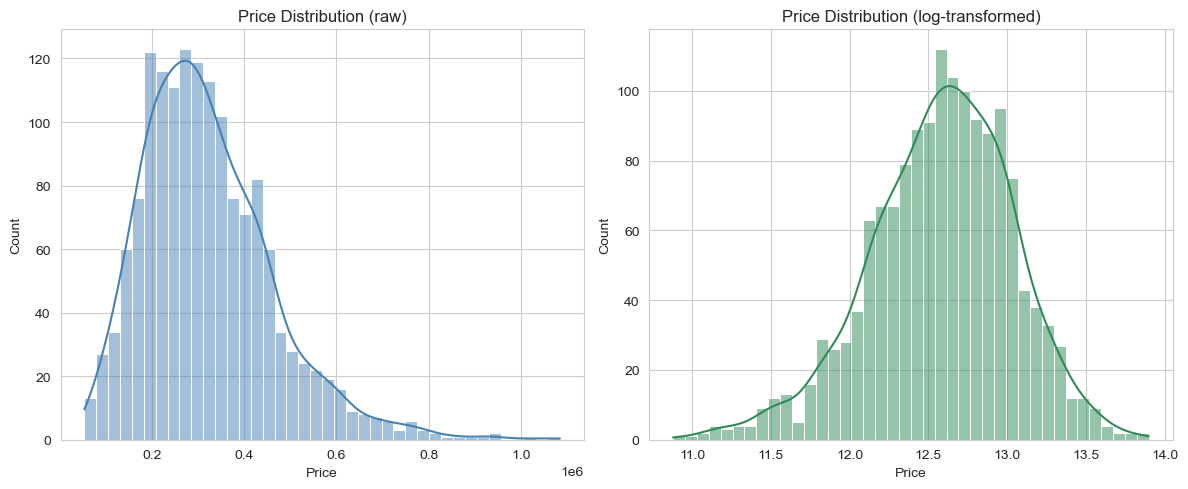

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df["Price"], kde=True, bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("Price Distribution (raw)")

sns.histplot(np.log1p(df["Price"]), kde=True, bins=40, ax=axes[1], color="seagreen")
axes[1].set_title("Price Distribution (log-transformed)")
plt.tight_layout()
plt.show()

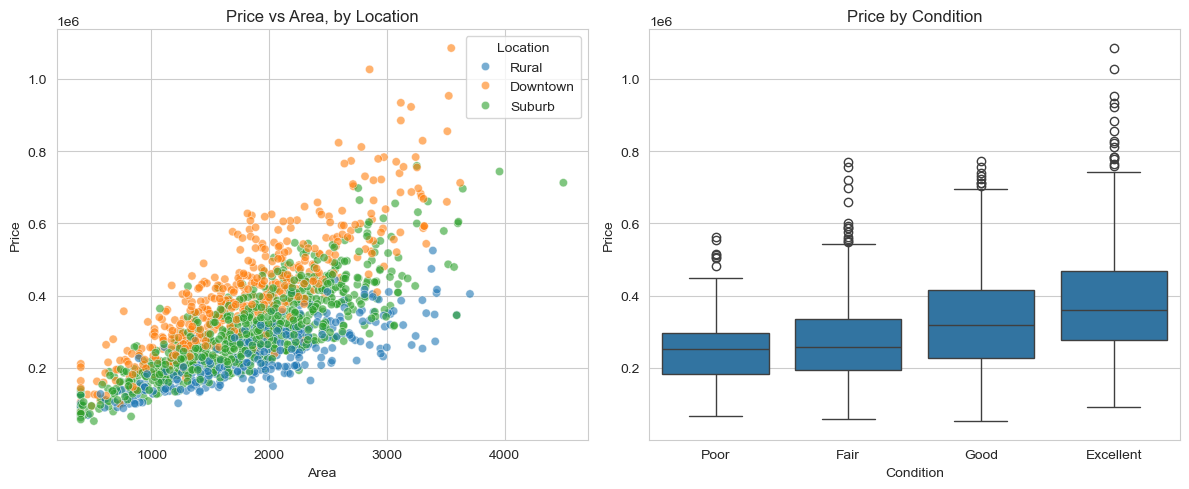

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=df, x="Area", y="Price", hue="Location", alpha=0.6, ax=axes[0])
axes[0].set_title("Price vs Area, by Location")

sns.boxplot(data=df, x="Condition", y="Price",
            order=["Poor", "Fair", "Good", "Excellent"], ax=axes[1])
axes[1].set_title("Price by Condition")
plt.tight_layout()
plt.show()

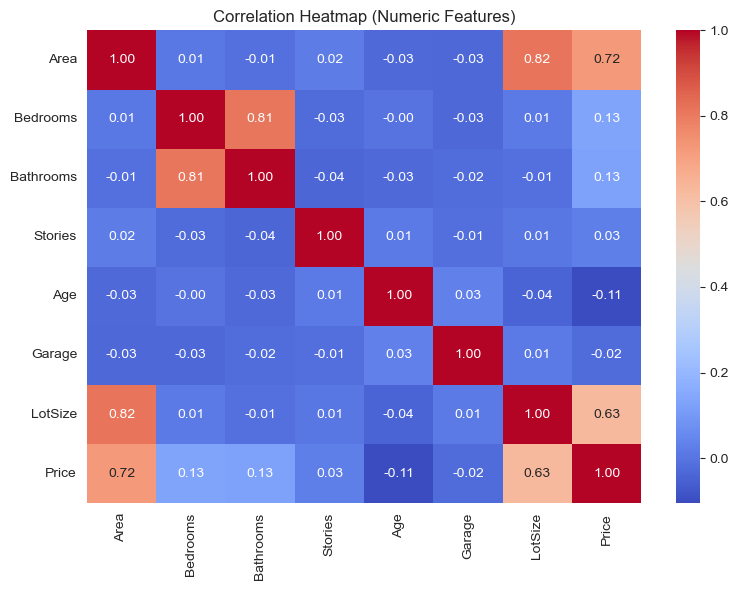

In [8]:
numeric_cols = ["Area", "Bedrooms", "Bathrooms", "Stories", "Age", "Garage", "LotSize", "Price"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

In [9]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["LotSize"] = df["LotSize"].fillna(df["LotSize"].median())

df["LogPrice"] = np.log1p(df["Price"])

model_df = pd.get_dummies(df.drop(columns=["Price"]), columns=["Location", "Condition"], drop_first=True)
model_df.head()

,Area,Bedrooms,Bathrooms,Stories,Age,Garage,LotSize,LogPrice,Location_Rural,Location_Suburb,Condition_Fair,Condition_Good,Condition_Poor
0,2148.0,3,2,3,12.1,2,5382.0,12.645942,True,False,False,True,False
1,1703.0,5,4,2,9.9,2,2748.0,12.937240,False,False,True,False,False
2,2253.0,3,3,2,2.0,1,2708.0,13.091081,False,False,True,False,False
3,2866.0,2,2,2,11.3,1,7129.0,13.166574,False,False,True,False,False
4,1636.0,2,1,1,4.7,1,2467.0,12.565846,False,True,False,False,False


In [10]:
X = model_df.drop(columns=["LogPrice"])
y = model_df["LogPrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

numeric_features = ["Area", "Bedrooms", "Bathrooms", "Stories", "Age", "Garage", "LotSize"]
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (1200, 12)  Test shape: (300, 12)


In [11]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE),
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

print("All models trained.")

All models trained.


In [12]:
results = []
predictions = {}

for name, model in models.items():
    log_preds = model.predict(X_test_scaled)
    preds = np.expm1(log_preds)
    actual = np.expm1(y_test)
    predictions[name] = preds

    rmse = np.sqrt(mean_squared_error(actual, preds))
    mae = mean_absolute_error(actual, preds)
    r2 = r2_score(actual, preds)

    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2})

results_df = pd.DataFrame(results).set_index("Model").round(2)
results_df

,RMSE,MAE,R2
Model,,,
Linear Regression,55393.04,37986.18,0.86
Random Forest,59051.17,39254.11,0.84
Gradient Boosting,49027.56,34354.14,0.89


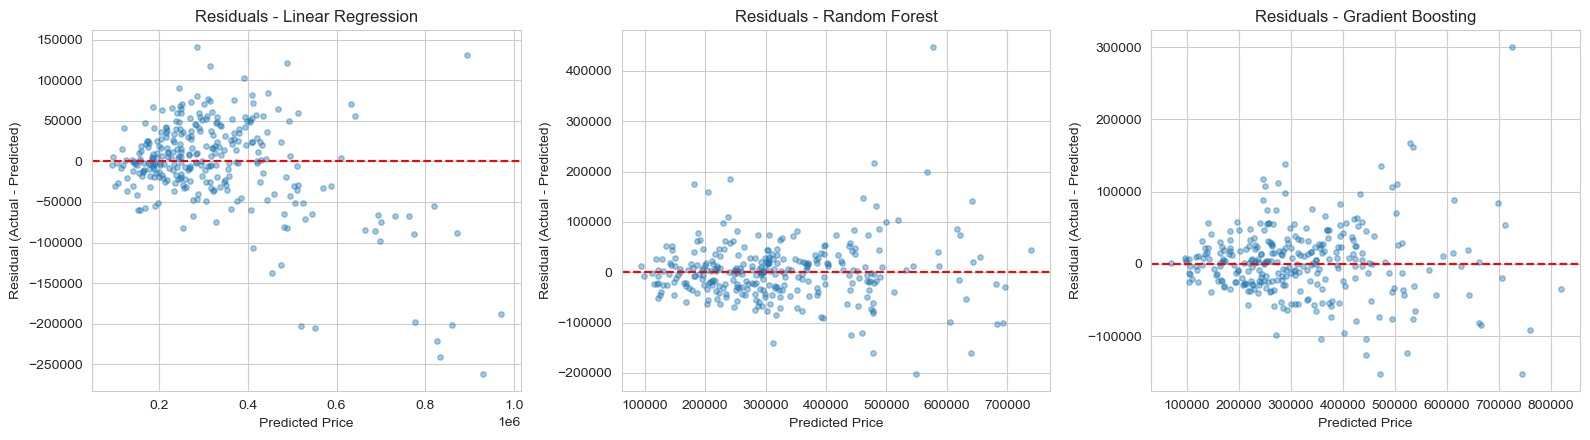

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
actual = np.expm1(y_test)

for ax, (name, preds) in zip(axes, predictions.items()):
    residuals = actual - preds
    ax.scatter(preds, residuals, alpha=0.4, s=15)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_title(f"Residuals - {name}")
    ax.set_xlabel("Predicted Price")
    ax.set_ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()

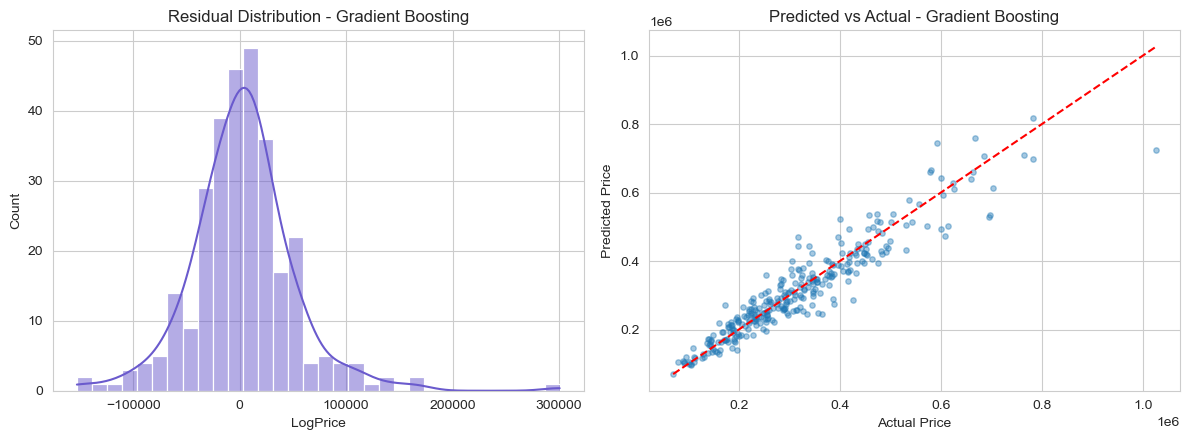

Best model by RMSE: Gradient Boosting


In [14]:
BEST_MODEL_NAME = results_df["RMSE"].idxmin()
best_preds = predictions[BEST_MODEL_NAME]
residuals = actual - best_preds

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(residuals, kde=True, ax=axes[0], color="slateblue")
axes[0].set_title(f"Residual Distribution - {BEST_MODEL_NAME}")

axes[1].scatter(actual, best_preds, alpha=0.4, s=15)
lims = [actual.min(), actual.max()]
axes[1].plot(lims, lims, color="red", linestyle="--")
axes[1].set_title(f"Predicted vs Actual - {BEST_MODEL_NAME}")
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")

plt.tight_layout()
plt.show()
print("Best model by RMSE:", BEST_MODEL_NAME)

In [15]:
best_model = models[BEST_MODEL_NAME]

joblib.dump(best_model, "house_price_model.pkl")
joblib.dump(scaler, "house_price_scaler.pkl")
joblib.dump(list(X_train.columns), "house_price_feature_columns.pkl")
joblib.dump(numeric_features, "house_price_numeric_features.pkl")

print("Saved: house_price_model.pkl, house_price_scaler.pkl, "
      "house_price_feature_columns.pkl, house_price_numeric_features.pkl")

Saved: house_price_model.pkl, house_price_scaler.pkl, house_price_feature_columns.pkl, house_price_numeric_features.pkl


In [16]:
def predict_house_price(raw_house: dict):
    '''
    raw_house: dict with keys matching the ORIGINAL raw columns, e.g.:
        {
            "Area": 2200, "Bedrooms": 4, "Bathrooms": 3, "Stories": 2,
            "Age": 5, "Garage": 2, "LotSize": 4500,
            "Location": "Suburb", "Condition": "Good"
        }
    '''
    model = joblib.load("house_price_model.pkl")
    scaler = joblib.load("house_price_scaler.pkl")
    feature_columns = joblib.load("house_price_feature_columns.pkl")
    numeric_features = joblib.load("house_price_numeric_features.pkl")

    input_df = pd.DataFrame([raw_house])
    input_df = pd.get_dummies(input_df, columns=["Location", "Condition"], drop_first=True)
    input_df = input_df.reindex(columns=feature_columns, fill_value=0)
    input_df[numeric_features] = scaler.transform(input_df[numeric_features])

    log_pred = model.predict(input_df)[0]
    price_pred = np.expm1(log_pred)
    return {"predicted_price": round(float(price_pred), 2)}


example_house = {
    "Area": 2200, "Bedrooms": 4, "Bathrooms": 3, "Stories": 2,
    "Age": 5, "Garage": 2, "LotSize": 4500,
    "Location": "Suburb", "Condition": "Good",
}

predict_house_price(example_house)

{'predicted_price': 591902.49}